# MOVIE RATING PREDICTION WITH PYTHON

---



*   Build a model that predicts the rating of a movie based on
features like genre, director, and actors. You can use regression
techniques to tackle this problem.

*   The goal is to analyze historical movie data and develop a model
that accurately estimates the rating given to a movie by users or
critics.


*   Movie Rating Prediction project enables you to explore data
analysis, preprocessing, feature engineering, and machine
learning modeling techniques. It provides insights into the factors
that influence movie ratings and allows you to build a model that
can estimate the ratings of movies accurately.





Dataset: https://www.kaggle.com/datasets/adrianmcmahon/imdb-india-movies

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

mr = pd.read_csv(
    "/content/drive/MyDrive/Pandas/Dataset/IMDbMoviesIndia.csv",
    encoding="latin-1"
)

In [ ]:
mr.head(6)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor


In [ ]:
mr.tail(6)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
15503,Zulm Ki Zanjeer,(1989),125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN
15508,Zulm-O-Sitam,(1998),130 min,"Action, Drama",6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [ ]:
mr.shape

(15509, 10)

In [ ]:
mr.dtypes

,0
Name,object
Year,object
Duration,object
Genre,object
Rating,float64
Votes,object
Director,object
Actor 1,object
Actor 2,object
Actor 3,object


In [ ]:
# Display Column Names

mr.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [ ]:
# Understand the Dataset Structure
mr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
# Statistical Summary of Numerical Columns
mr.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [ ]:
# Summary of Categorical Columns
mr.describe(include="object")

,Name,Year,Duration,Genre,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7920,14984,13892,13125,12365
unique,13838,102,182,485,2034,5938,4718,4891,4820
top,Mamta,(2019),120 min,Drama,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,227,58,158,83,91


In [ ]:
# View Random Rows
mr.sample(5)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
14692,Uttara Abhimanyu,(1946),NaN,NaN,NaN,NaN,Sarvottam Badami,Ashok Kumar,Chhayadevi,Shahu Modak
2106,Bhai Aakhir Bhai Hota Hai,(1982),NaN,Drama,NaN,NaN,R.C. Nanda,Vikram Makandar,Kumari Naaz,Monty Nath
8876,Maqbool,(2003),132 min,"Crime, Drama, Thriller",8.1,"10,024",Vishal Bhardwaj,Irrfan Khan,Tabu,Pankaj Kapur
13379,Sonthakkaran,(1989),NaN,"Action, Comedy, Drama",NaN,NaN,Raja,Arjun Sarja,Madhuri,Nirosha
3519,De Dana Dan,(2009),162 min,"Action, Comedy, Crime",5.5,"7,758",Priyadarshan,Akshay Kumar,Sunil Shetty,Katrina Kaif


In [ ]:
# Identify the Target Variable
Target = mr['Rating']

In [ ]:
# Check Missing Values
missing = mr.isnull().sum()
missing

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [ ]:
# Calculate Missing Percentage
missing_percentage = (missing/len(mr))*100
missing_percentage

,0
Name,0.000000
Year,3.404475
Duration,53.317429
Genre,12.102650
Rating,48.939326
Votes,48.932878
Director,3.385131
Actor 1,10.426204
Actor 2,15.371720
Actor 3,20.272100


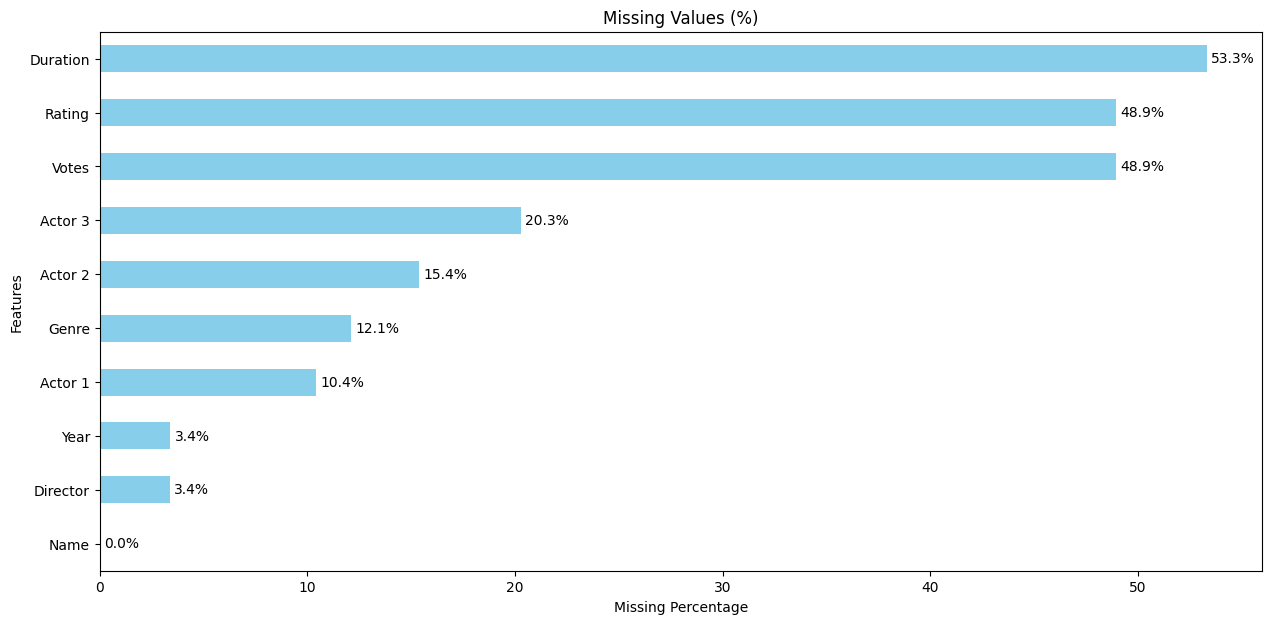

In [ ]:
# Visualize Missing Values
# 1. Setup figure size for readability
plt.figure(figsize=(15, 7))
# 2. Plot the sorted values (returns an Axes object)
ax = missing_percentage.sort_values().plot(kind="barh", color="skyblue")

# 3. Add labels, titles, and the bar values
plt.xlabel("Missing Percentage")
plt.ylabel("Features")
plt.title("Missing Values (%)")

# 4. Fix: Pass the container inside the axes to bar_label
plt.bar_label(ax.containers[0], padding=3, fmt="%.1f%%")

# 5. Render
plt.show()



In [ ]:
# Check Duplicate Rows

mr.duplicated().sum()


np.int64(6)

In [ ]:
mr[mr.duplicated()]

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1250,Arab Ka Sona - Abu Kaalia,(1979),NaN,Action,NaN,NaN,Master Bhagwan,Meena Rai,Dara Singh,NaN
1769,Balidan,(1992),NaN,Drama,NaN,NaN,NaN,NaN,NaN,NaN
4723,First Time - Pehli Baar,(2009),NaN,NaN,NaN,NaN,Raja Bundela,Zeenat Aman,Nitin Arora,Raj Babbar
9713,Musafir,NaN,NaN,Thriller,NaN,NaN,Shiva Dagar,NaN,NaN,NaN
13069,Shivani,(2019),NaN,Crime,NaN,NaN,Ugresh Prasad Ujala,Santosh,NaN,NaN
13308,Slumdog Karodpati,(2019),118 min,Thriller,NaN,NaN,Rajesh Patole,Udhav Garje,Rahul Gavane,Govindrao


In [ ]:
mr.drop_duplicates(inplace=True)

In [ ]:
mr.shape

(15503, 10)

In [ ]:
# Check Data Types
mr.dtypes

,0
Name,object
Year,object
Duration,object
Genre,object
Rating,float64
Votes,object
Director,object
Actor 1,object
Actor 2,object
Actor 3,object


In [ ]:
mr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15503 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15503 non-null  object 
 1   Year      14976 non-null  object 
 2   Duration  7239 non-null   object 
 3   Genre     13627 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14979 non-null  object 
 7   Actor 1   13888 non-null  object 
 8   Actor 2   13122 non-null  object 
 9   Actor 3   12363 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.3+ MB


In [ ]:
# Inspect Unique Values
mr["Genre"].unique()

array(['Drama', 'Drama, Musical', 'Comedy, Romance',
       'Comedy, Drama, Musical', 'Drama, Romance, War', 'Documentary',
       'Horror, Mystery, Thriller', 'Action, Crime, Thriller', 'Horror',
       'Horror, Romance, Thriller', 'Comedy, Drama, Romance', 'Thriller',
       'Comedy, Drama', nan, 'Comedy, Drama, Fantasy',
       'Comedy, Drama, Family', 'Crime, Drama, Mystery',
       'Horror, Thriller', 'Biography', 'Comedy, Horror', 'Action',
       'Drama, Horror, Mystery', 'Comedy', 'Action, Thriller',
       'Drama, History', 'Drama, History, Sport',
       'Horror, Mystery, Romance', 'Horror, Mystery',
       'Drama, Horror, Romance', 'Action, Drama, History',
       'Action, Drama, War', 'Comedy, Family',
       'Adventure, Horror, Mystery', 'Action, Sci-Fi',
       'Crime, Mystery, Thriller', 'War', 'Sport',
       'Biography, Drama, History', 'Horror, Romance', 'Crime, Drama',
       'Drama, Romance', 'Adventure, Drama', 'Comedy, Mystery, Thriller',
       'Action, Crime, Dr

In [ ]:
# Count unique values:
mr["Genre"].nunique()

485

In [ ]:
# Most frequent values:
mr["Genre"].value_counts().head(10)

,count
Genre,
Drama,2779
Action,1288
Thriller,777
Romance,708
"Drama, Romance",524
Comedy,495
"Action, Crime, Drama",455
"Drama, Family",418
Horror,322


In [ ]:
# Clean Text Columns
mr["Genre"] = mr["Genre"].str.strip()

In [ ]:
object_columns = mr.select_dtypes(include="object").columns
for col in object_columns:
    mr[col] = mr[col].str.strip()

In [ ]:
object_columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1',
       'Actor 2', 'Actor 3'],
      dtype='object')

In [ ]:
# Explore Numeric Columns
mr.select_dtypes(include=["number"]).columns

Index(['Rating'], dtype='object')

In [ ]:
mr.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


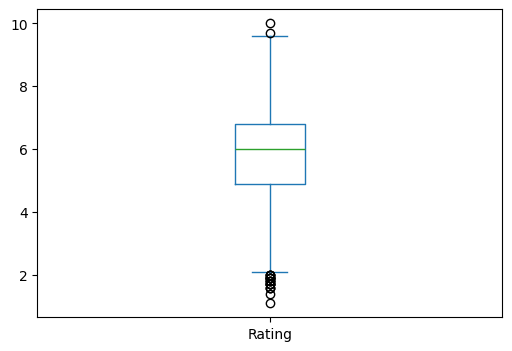

In [ ]:
# Detect Outliers
plt.figure(figsize=(6,4))

mr["Rating"].plot(kind="box")

plt.show()

In [ ]:
# Inspect Each Column

for col in mr.columns:
    print("=" * 50)
    print(col)
    print(mr[col].head())
    print()

Name
0                                      
1    #Gadhvi (He thought he was Gandhi)
2                           #Homecoming
3                               #Yaaram
4                     ...And Once Again
Name: Name, dtype: object

Year
0       NaN
1    (2019)
2    (2021)
3    (2019)
4    (2010)
Name: Year, dtype: object

Duration
0        NaN
1    109 min
2     90 min
3    110 min
4    105 min
Name: Duration, dtype: object

Genre
0              Drama
1              Drama
2     Drama, Musical
3    Comedy, Romance
4              Drama
Name: Genre, dtype: object

Rating
0    NaN
1    7.0
2    NaN
3    4.4
4    NaN
Name: Rating, dtype: float64

Votes
0    NaN
1      8
2    NaN
3     35
4    NaN
Name: Votes, dtype: object

Director
0         J.S. Randhawa
1         Gaurav Bakshi
2    Soumyajit Majumdar
3            Ovais Khan
4          Amol Palekar
Name: Director, dtype: object

Actor 1
0        Manmauji
1    Rasika Dugal
2    Sayani Gupta
3         Prateik
4    Rajat Kapoor
Name: Actor 1

In [ ]:
# Create a Data Quality Report

quality = pd.DataFrame({
    "Data Type": mr.dtypes,
    "Missing": mr.isnull().sum(),
    "Missing %": round((mr.isnull().sum() / len(mr)) * 100, 2),
    "Unique": mr.nunique()
})

quality

,Data Type,Missing,Missing %,Unique
Name,object,0,0.00,13838
Year,object,527,3.40,102
Duration,object,8264,53.31,182
Genre,object,1876,12.10,485
Rating,float64,7584,48.92,84
Votes,object,7583,48.91,2034
Director,object,524,3.38,5938
Actor 1,object,1615,10.42,4718
Actor 2,object,2381,15.36,4891
Actor 3,object,3140,20.25,4820


# Exploratory Data Analysis (EDA)

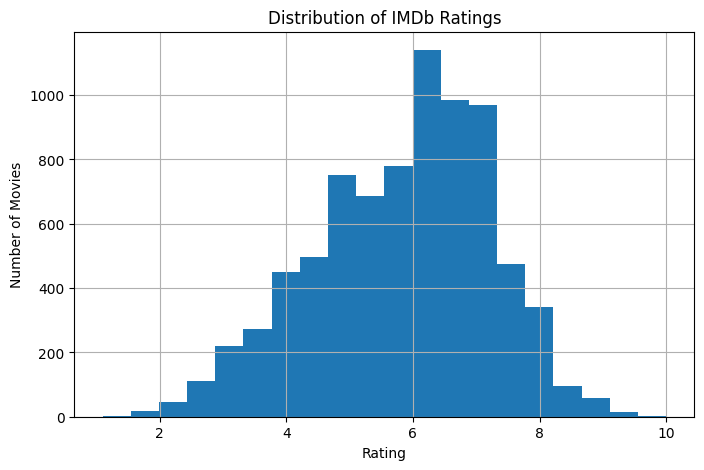

In [ ]:
plt.figure(figsize=(8,5))
mr["Rating"].hist(bins=20)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

In [ ]:
# Movie Duration Distribution
mr["Duration"].value_counts().head()

,count
Duration,
120 min,240
135 min,173
130 min,171
140 min,167
150 min,154


<Axes: >

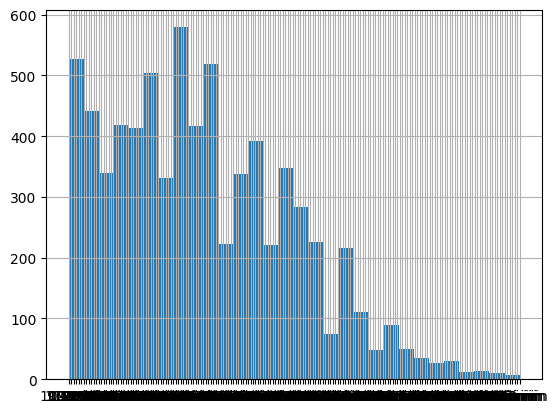

In [ ]:
# After cleaning the duration column
mr["Duration"].hist(bins=30)


In [ ]:
# Genre Distribution
mr["Genre"].value_counts().head(15)

,count
Genre,
Drama,2779
Action,1288
Thriller,777
Romance,708
"Drama, Romance",524
Comedy,495
"Action, Crime, Drama",455
"Drama, Family",418
Horror,322


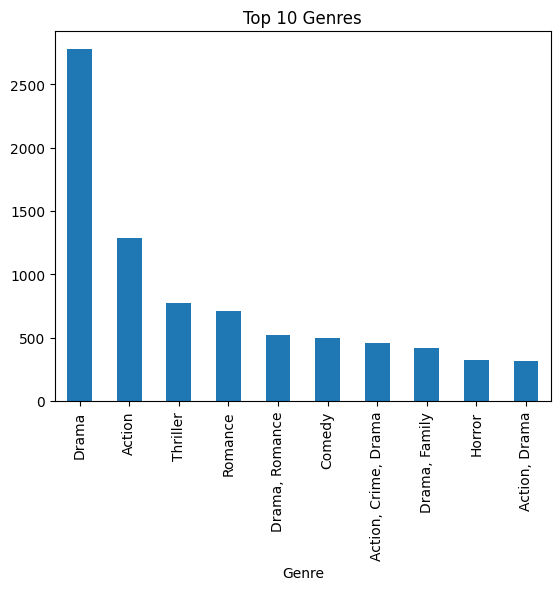

In [ ]:
# Visualization
mr["Genre"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Genres")

plt.show()

In [ ]:
# Movies Released Each Year
mr["Year"].value_counts().sort_index()


,count
Year,
(1913),1
(1914),1
(1915),1
(1917),1
(1922),1
...,...
(2018),381
(2019),408
(2020),320


<Axes: xlabel='Year'>

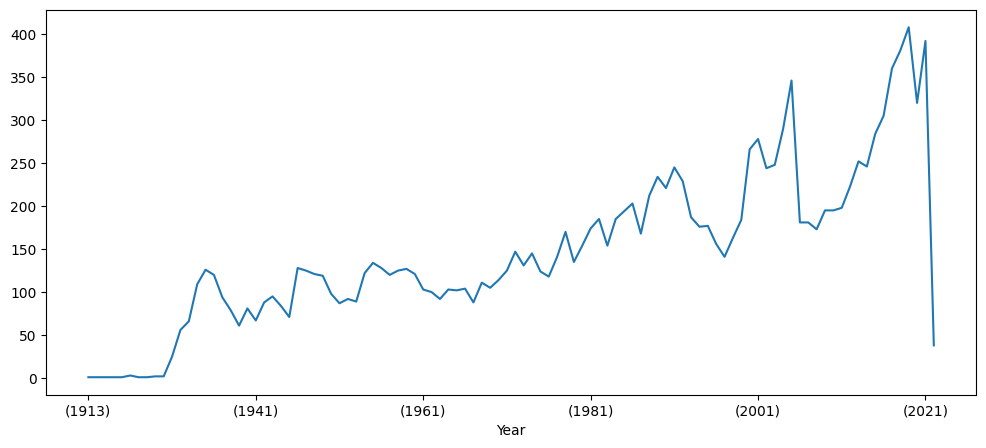

In [ ]:
mr["Year"].value_counts().sort_index().plot(figsize=(12,5))

In [ ]:
# Director Analysis
mr["Director"].value_counts().head(10)

,count
Director,
Jayant Desai,58
Kanti Shah,57
Babubhai Mistry,50
Mahesh Bhatt,48
Dhirubhai Desai,46
Master Bhagwan,46
Nanabhai Bhatt,46
David Dhawan,44
Mohammed Hussain,44


In [ ]:
# Actor Analysis
mr["Actor 1"].value_counts().head(10)

,count
Actor 1,
Ashok Kumar,158
Jeetendra,140
Dharmendra,140
Mithun Chakraborty,133
Amitabh Bachchan,129
Rajesh Khanna,122
Dev Anand,93
Shashi Kapoor,91
Akshay Kumar,88


In [ ]:
mr["Actor 2"].value_counts().head(10)

,count
Actor 2,
Rekha,83
Hema Malini,72
Mithun Chakraborty,63
Dharmendra,61
Mala Sinha,48
Helen,48
Mumtaz,45
Reena Roy,45
Jaya Prada,44


In [ ]:
mr["Actor 3"].value_counts().head(10)

,count
Actor 3,
Pran,91
Shakti Kapoor,65
Anupam Kher,64
Jeevan,59
Prem Chopra,52
Aruna Irani,47
Mithun Chakraborty,45
Shatrughan Sinha,45
Nirupa Roy,43


In [ ]:
# Votes Distribution

mr["Votes"].describe()

,Votes
count,7920
unique,2034
top,8
freq,227


In [ ]:
mr['Duration']

,Duration
0,NaN
1,109 min
2,90 min
3,110 min
4,105 min
...,...
15504,NaN
15505,129 min
15506,NaN
15507,NaN


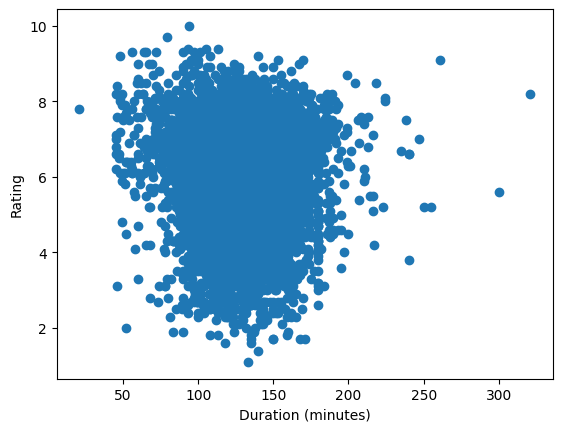

In [ ]:
# Clean and convert 'Duration' to numeric
mr['Duration_cleaned'] = mr['Duration'].str.extract(r'(\d+)').astype(float)

plt.scatter(
    mr["Duration_cleaned"],
    mr["Rating"]
)

plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")

plt.show()

### Clean and Analyze Votes Distribution

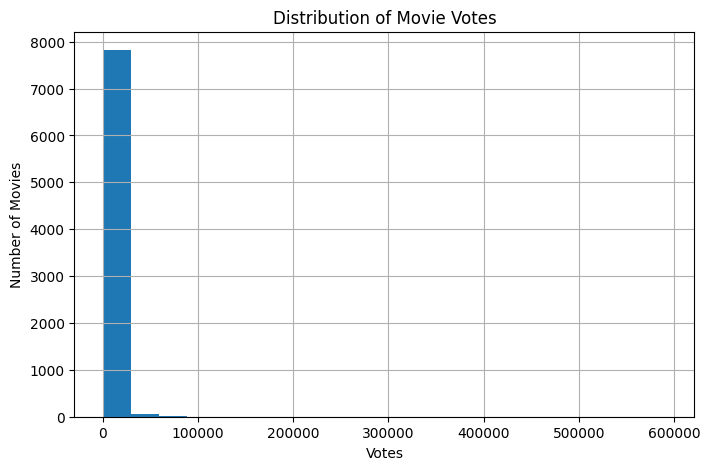

In [ ]:
# Clean and convert 'Votes' to numeric
mr['Votes_cleaned'] = mr['Votes'].str.replace(',', '', regex=False).str.replace('$', '', regex=False).str.replace('M', '', regex=False).astype(float)

plt.figure(figsize=(8,5))
mr['Votes_cleaned'].hist(bins=20)

plt.title("Distribution of Movie Votes")
plt.xlabel("Votes")
plt.ylabel("Number of Movies")

plt.show()

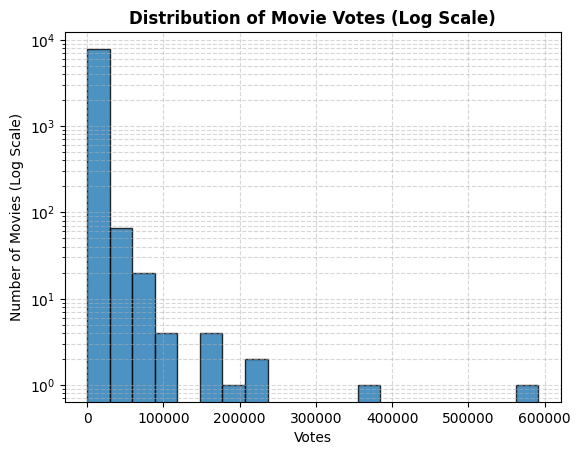

In [ ]:
# Plot the histogram with 20 bins
plt.hist(mr["Votes_cleaned"], bins=20, edgecolor="black", alpha=0.8)

# Transform the y-axis to a logarithmic scale to reveal the squished bars
plt.yscale("log")

# Add grid lines that match the log scale for easier reading
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Label the axes and title
plt.xlabel("Votes")
plt.ylabel("Number of Movies (Log Scale)")
plt.title("Distribution of Movie Votes (Log Scale)", fontsize=12, fontweight="bold")

# Display the plot
plt.show()

In [ ]:
# Highest Rated Movies
mr.sort_values("Rating", ascending=False).head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Duration_cleaned,Votes_cleaned
8339,Love Qubool Hai,(2020),94 min,"Drama, Romance",10.0,5,Saif Ali Sayeed,Ahaan Jha,Mahesh Narayan,Rajasree Rajakumari,94.0,5.0
5410,Half Songs,(2021),79 min,"Music, Romance",9.7,7,Sriram Raja,Raj Banerjee,Emon Chatterjee,Purshottam Mulani,79.0,7.0
2563,Breed,(2020),NaN,Drama,9.6,48,Bobby Kumar,Bobby Kumar,Ashfaq,Fasih Choudhry,NaN,48.0
5077,Gho Gho Rani,(2019),105 min,"History, Romance",9.4,47,Munni Pankaj,Nishi Neha Mishra,Pankaj Kamal,Akash Kumar,105.0,47.0
14222,The Reluctant Crime,(2020),113 min,Drama,9.4,16,Arvind Pratap,Dharmendra Ahir,Awanish Kotnal,Rakhi Mansha,113.0,16.0
6852,June,(2021),93 min,Drama,9.4,18,Suhrud Godbole,Vaibhav Khisti,Nilesh Divekar,Jitendra Joshi,93.0,18.0
11704,Ram-Path,(2017),NaN,Documentary,9.4,5,Ashish Dubey,Ishan Jacob,NaN,NaN,NaN,5.0
9105,Meher,(2020),NaN,Drama,9.3,27,Rajat Bhardwaj,Amrit,Dimple Chauhan,Sapna Das,NaN,27.0
5125,God of gods,(2019),90 min,Documentary,9.3,46,Venkatesh Bk,Tejaswini Manogna,Triyug Mantri,Raj Singh Verma,90.0,46.0
11843,Refl3ct,(2021),65 min,Sci-Fi,9.3,467,Nikhil Mahar,Vijay Mahar,Vijay Mahar,Nikhil Mahar,65.0,467.0


# Feature Engineering

In [ ]:
# transforms raw data into meaningful information.

In [ ]:
# Clean Existing Features

In [ ]:
# Year
mr["Year"] = (
    mr["Year"]
      .str.extract(r"(\d{4})")
      .astype("float")
)

In [ ]:
# Duration
mr["Duration"]=(mr["Duration"].str.extract(r"(\d+)").astype("float"))

In [ ]:
# Create New Features
CURRENT_YEAR = 2026

mr["Movie_Age"] = CURRENT_YEAR - mr["Year"]

In [ ]:
# Number of Genres
mr["Genre_Count"] = mr["Genre"].str.count(",") + 1

In [ ]:
# Director Movie Count
director_count = mr["Director"].value_counts()

mr["Director_Movie_Count"] = mr["Director"].map(director_count)


In [ ]:
mr["Director_Movie_Count"]

,Director_Movie_Count
0,2.0
1,1.0
2,1.0
3,1.0
4,7.0
...,...
15504,4.0
15505,8.0
15506,1.0
15507,NaN


In [ ]:
director_table = director_count.reset_index()
director_table.columns = ["Director Name", "Total Movies"]
print(director_table.head(10))

      Director Name  Total Movies
0      Jayant Desai            58
1        Kanti Shah            57
2   Babubhai Mistry            50
3      Mahesh Bhatt            48
4   Dhirubhai Desai            46
5    Master Bhagwan            46
6    Nanabhai Bhatt            46
7      David Dhawan            44
8  Mohammed Hussain            44
9       B.R. Ishara            44


In [ ]:
mr.head(3)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Duration_cleaned,Votes_cleaned,Movie_Age,Genre_Count,Director_Movie_Count
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia,NaN,NaN,NaN,1.0,2.0
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,109.0,8.0,7.0,1.0,1.0
2,#Homecoming,2021.0,90.0,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana,90.0,NaN,5.0,2.0,1.0


# Feature Selection

In [ ]:
clean_mr = mr.drop(
    columns=["Year", "Name"]
)

# Display the cleaned DataFrame
clean_mr.dropna(inplace=True)
clean_mr.shape

(5659, 13)

In [ ]:
clean_mr.head(10)

,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Duration_cleaned,Votes_cleaned,Movie_Age,Genre_Count,Director_Movie_Count
1,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,109.0,8.0,7.0,1.0,1.0
3,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,110.0,35.0,7.0,2.0,1.0
5,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,147.0,827.0,29.0,3.0,17.0
6,142.0,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,142.0,1086.0,21.0,3.0,7.0
8,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,82.0,326.0,14.0,3.0,1.0
9,116.0,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon,116.0,11.0,12.0,3.0,1.0
10,96.0,Drama,6.2,17,Madhu Ambat,Rati Agnihotri,Gulshan Grover,Atul Kulkarni,96.0,17.0,22.0,1.0,1.0
11,120.0,Horror,5.9,59,Arshad Siddiqui,Pankaj Berry,Anubhav Dhir,Hritu Dudani,120.0,59.0,10.0,1.0,3.0
12,161.0,"Horror, Romance, Thriller",6.5,983,Partho Ghosh,Jackie Shroff,Madhuri Dixit,Javed Jaffrey,161.0,983.0,35.0,3.0,23.0
13,166.0,"Comedy, Drama, Romance",5.7,512,Rabi Kinagi,Jeet,Koyel Mallick,Sujoy Ghosh,166.0,512.0,14.0,3.0,1.0


In [ ]:
# Separate Features and Target

X = clean_mr.drop(columns=["Rating"])
y = clean_mr["Rating"]


In [ ]:
# Identify Numerical and Categorical Columns

# Numerical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Duration', 'Duration_cleaned', 'Votes_cleaned', 'Movie_Age', 'Genre_Count', 'Director_Movie_Count']
Categorical Columns: ['Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [ ]:
# Split the Data
# Always split before preprocessing to avoid data leakage.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Encode Categorical Features

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [ ]:
# Scale Numerical Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, num_cols),
        ("cat", encoder, cat_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Duration', 'Duration_cleaned',
                                  'Votes_cleaned', 'Movie_Age', 'Genre_Count',
                                  'Director_Movie_Count']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Genre', 'Votes', 'Director', 'Actor 1',
                                  'Actor 2', 'Actor 3'])])

In [ ]:
# Transform the Data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
# Check the Shape

print("Original Shape :", X_train.shape)
print("Processed Shape:", X_train_processed.shape)

Original Shape : (4527, 12)
Processed Shape: (4527, 10049)


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__Duration' 'num__Duration_cleaned' 'num__Votes_cleaned' ...
 'cat__Actor 3_Zeeshan Khan' 'cat__Actor 3_Zeishan Quadri'
 'cat__Actor 3_Zoya Hussain']


In [ ]:

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_processed.head()

,num__Duration,num__Duration_cleaned,num__Votes_cleaned,num__Movie_Age,num__Genre_Count,num__Director_Movie_Count,cat__Genre_Action,"cat__Genre_Action, Adventure","cat__Genre_Action, Adventure, Biography","cat__Genre_Action, Adventure, Comedy",...,cat__Actor 3_Zala Akash,cat__Actor 3_Zara Barring,cat__Actor 3_Zara Shah,cat__Actor 3_Zareen Khan,cat__Actor 3_Zarine Ali,cat__Actor 3_Zayed Khan,cat__Actor 3_Zeenat Aman,cat__Actor 3_Zeeshan Khan,cat__Actor 3_Zeishan Quadri,cat__Actor 3_Zoya Hussain
9424,0.379044,0.379044,-0.199552,-1.001742,-1.344689,-0.823538,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12009,0.776286,0.776286,-0.198331,2.760256,-1.344689,0.997655,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4316,0.537941,0.537941,-0.167804,0.370879,1.067120,0.043697,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6897,0.220146,0.220146,-0.166942,1.794337,1.067120,-0.129750,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2338,-2.361932,-2.361932,-0.198906,-0.798390,-1.344689,-0.736814,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Train Machine Learning Models

In [ ]:
# Import the Model
from sklearn.linear_model import LinearRegression

# Create the Model
lr = LinearRegression()

# Train the Model
lr.fit(X_train_processed, y_train)

# Make Predictions
y_pred = lr.predict(X_test_processed)

# Compare Predictions
prediction = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Actual,Predicted
10971,6.0,4.911081
14052,2.4,5.631344
10002,3.8,5.054594
3970,3.8,5.871357
8840,7.2,6.364020
5071,6.3,4.705182
2709,8.6,5.025099
11842,3.9,5.642961
10910,6.6,4.795363
4485,6.6,7.077463


In [ ]:
# Look at the Coefficients

coef = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Coefficient": lr.coef_
})

coef.head()

,Feature,Coefficient
0,num__Duration,-0.018612
1,num__Duration_cleaned,-0.018612
2,num__Votes_cleaned,0.195448
3,num__Movie_Age,0.453454
4,num__Genre_Count,-0.075749


In [ ]:
# Intercept

print(lr.intercept_)

6.367848236599612


# Model Evaluation

In [ ]:
# Import Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# Calculate MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.1510102990337103


In [ ]:
# Calculate MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 2.1251062712943347


In [ ]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1.4577744240088502


In [ ]:
# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.1476244434451215


In [ ]:
# Display All Metrics Together
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

results

,Metric,Value
0,MAE,1.151010
1,MSE,2.125106
2,RMSE,1.457774
3,R² Score,-0.147624


# Improve Model Performance

In [ ]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_processed, y_train)

dt_pred = dt.predict(X_test_processed)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

MAE : 1.0377208480565372
RMSE: 1.4023547839007533
R²  : -0.06202548286752019


In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_processed, y_train)

rf_pred = rf.predict(X_test_processed)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 0.812434628975265
RMSE: 1.0989005137966834
R²  : 0.3478674320035613


In [ ]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train_processed, y_train)

gb_pred = gb.predict(X_test_processed)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Evaluate
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

MAE : 0.8775714395686495
RMSE: 1.135574596867219
R²  : 0.3036132902389904


In [ ]:
# Compare All Models
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.812435,1.098901,0.347867
3,Gradient Boosting,0.877571,1.135575,0.303613
1,Decision Tree,1.037721,1.402355,-0.062025
0,Linear Regression,1.151010,1.457774,-0.147624
